In [58]:
import time
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

### Check GPU Availability

In [3]:
if torch.cuda.is_available():
    print('Using GPU, device name:', torch.cuda.get_device_name(0))
    device = torch.device('cuda')
else:
    print('No GPU found, using CPU instead.') 
    device = torch.device('cpu')

No GPU found, using CPU instead.


In [5]:
x = torch.rand(10)
x.size()

torch.Size([10])

In [7]:
temp = torch.FloatTensor([10,15.5,13,100.7,18,23.5])
temp.size()

torch.Size([6])

In [11]:
california = fetch_california_housing()
california_tensor = torch.from_numpy(california.data)
print(california_tensor.size())

torch.Size([20640, 8])


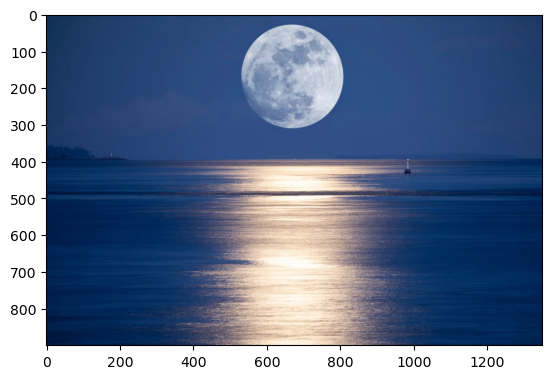

In [29]:
moon = np.array(Image.open('full_moon_rising_over_salish_sea.jpg'))
moon_tensor = torch.from_numpy(moon)
moon_tensor.size()
plt.imshow(moon)

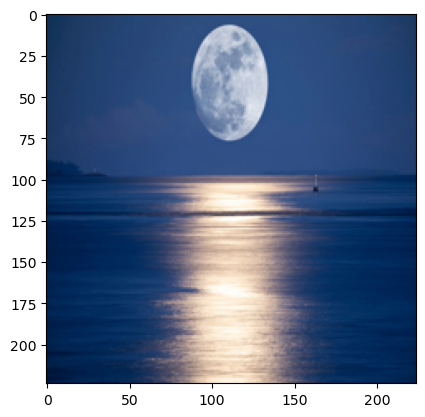

In [31]:
moon = np.array(Image.open('full_moon_rising_over_salish_sea.jpg').resize((224,224)))
moon_tensor = torch.from_numpy(moon)
moon_tensor.size()
plt.imshow(moon)

In [33]:
sales = torch.FloatTensor([1000.0,323.2,333.4,444.5,1000.0,323.2,333.4,444.5])
sales[:5]
 


tensor([1000.0000,  323.2000,  333.4000,  444.5000, 1000.0000])

In [34]:
sales[:-5]

tensor([1000.0000,  323.2000,  333.4000])

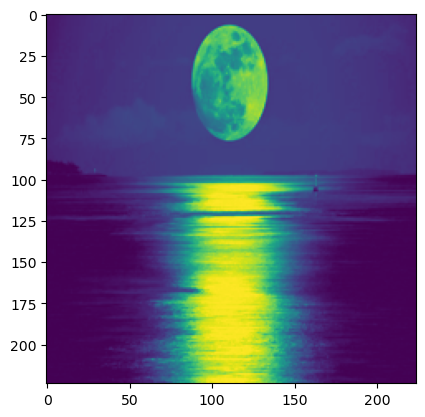

In [36]:
plt.imshow(moon_tensor[:,:,0].numpy())

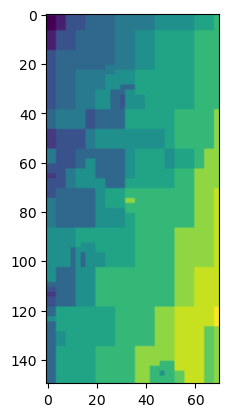

In [38]:
plt.imshow(panda_tensor[25:175,60:130,0].numpy())

In [44]:
test = torch.eye(3,3) #produces an diagonal matrix with 1 as it diagonal #elements.
test

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])

In [45]:
test[0,1]

tensor(0.)

# 4-D

In [51]:
from glob import glob
#Read cat images from disk
cats = glob('*.jpg')
#Convert images into numpy arrays
cat_imgs = np.array([np.array(Image.open(cat).resize((224,224))) for cat in
cats[:2]])
cat_imgs = cat_imgs.reshape(-1,224,224,3)
cat_tensors = torch.from_numpy(cat_imgs)
cat_tensors.size()

torch.Size([2, 224, 224, 3])

In [52]:
#Various ways you can perform tensor addition
a = torch.rand(2,2) 
b = torch.rand(2,2)
c = a + b
d = torch.add(a,b)
#For in-place addition
a.add_(5)

#Multiplication of different tensors

a*b
a.mul(b)
#For in-place multiplication
a.mul_(b)

tensor([[3.6481, 2.3398],
        [4.8116, 2.2808]])

In [60]:
a = torch.rand(10000,10000)
b = torch.rand(10000,10000)
start = time.time()
a.matmul(b)
end = time.time()
print(f"Matrix multiplication time on MPS: {end - start:.4f} seconds")
#Time taken : 3.23 s

Matrix multiplication time on MPS: 3.4223 seconds


In [59]:
#Move the tensors to GPU
#a = a.cuda()
#b = b.cuda()
a = a.to("mps")
b = b.to("mps")
start = time.time()
a.matmul(b)
end = time.time()
print(f"Matrix multiplication time on MPS: {end - start:.4f} seconds")
#Time taken : 11.2 µs  

Matrix multiplication time on MPS: 0.0037 seconds


In [62]:
import torch
print(torch.backends.mps.is_available())  # True means MPS works


True


# Variables

In [70]:
x = torch.ones(2,2,requires_grad=True)
y = x.mean()
y.backward()
x.grad

tensor([[0.2500, 0.2500],
        [0.2500, 0.2500]])

In [65]:
x.grad_fn

In [66]:
x.data

tensor([[1., 1.],
        [1., 1.]])

In [67]:
y.data

tensor(1.)

# Create data for NN

In [71]:
def get_data():
    train_X = np.asarray([3.3,4.4,5.5,6.71,6.93,4.168,9.779,6.182,7.59,2.167,
                         7.042,10.791,5.313,7.997,5.654,9.27,3.1])
    train_Y = np.asarray([1.7,2.76,2.09,3.19,1.694,1.573,3.366,2.596,2.53,1.221,
                         2.827,3.465,1.65,2.904,2.42,2.94,1.3])
    dtype = torch.FloatTensor
    X = torch.from_numpy(train_X).type(dtype).view(17, 1) 
    y = torch.from_numpy(train_Y).type(dtype) 

    return X,y

X, y = get_data()

In [72]:
X

tensor([[ 3.3000],
        [ 4.4000],
        [ 5.5000],
        [ 6.7100],
        [ 6.9300],
        [ 4.1680],
        [ 9.7790],
        [ 6.1820],
        [ 7.5900],
        [ 2.1670],
        [ 7.0420],
        [10.7910],
        [ 5.3130],
        [ 7.9970],
        [ 5.6540],
        [ 9.2700],
        [ 3.1000]])

In [73]:
y

tensor([1.7000, 2.7600, 2.0900, 3.1900, 1.6940, 1.5730, 3.3660, 2.5960, 2.5300,
        1.2210, 2.8270, 3.4650, 1.6500, 2.9040, 2.4200, 2.9400, 1.3000])

In [74]:
X.shape

torch.Size([17, 1])

In [75]:
y.shape

torch.Size([17])

# Create Learnable Parameters

In [76]:
def get_weights():
    w = torch.randn(1,requires_grad = True)
    b = torch.randn(1,requires_grad=True)
    return w,b


In [ ]:
def simple_network(x):
    y_pred = torch.matmul(x,w)+b
    return y_pred

def loss_fn(y,y_pred):
    loss = (y_pred-y).pow(2).sum()
    for param in [w,b]:
        if not param.grad is None: param.grad.data.zero_()
    loss.backward()
    return loss.data[0]

def optimize(learning_rate):
    w.data -= learning_rate * w.grad.data
    b.data -= learning_rate * b.grad.data



# Dataset Class

In [ ]:
from torch.utils.data import Dataset
class DogsAndCatsDataset(Dataset):
    def __init__(self,):
        pass
    def __len__(self):
        pass
    def __getitem__(self,idx):
        pass

class DogsAndCatsDataset(Dataset):
     def __init__(self,root_dir,size=(224,224)):
        self.files = glob(root_dir)
        self.size = size 
         def __len__(self):
        return len(self.files)



In [ ]:
def __getitem__(self,idx):
        img = np.asarray(Image.open(self.files[idx]).resize(self.size))
        label = self.files[idx].split('/')[-2]
        return img,label

dataloader = DataLoader(dogsdset,batch_size=32,num_workers=2)
for imgs , labels in dataloader:
     #Apply your DL on the dataset.
     pass

